# Recurrent Neural Net



In [136]:
%matplotlib inline

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [137]:
csv_path = "./data/epidemic_process_raw_data.csv"
df = pd.read_csv(csv_path)
df.head(4)

,1,2,3,4,5,6,7,8,9,10,...,492,493,494,495,496,497,498,499,500,501
0,100.287149,103.541223,95.879814,96.354848,96.980932,97.855310,98.940537,100.187494,98.265709,95.307794,...,4.925236,4.922108,4.918981,4.915853,4.912726,4.950240,4.995291,5.040342,5.085393,5.130445
1,0.993774,1.017558,1.070030,1.116168,1.142078,1.134735,1.182418,1.272310,1.356565,1.438978,...,0.391775,0.384359,0.376942,0.369526,0.362109,0.356669,0.351595,0.346521,0.341447,0.336374
2,0.000000,0.017741,0.036585,0.054735,0.074266,0.096065,0.117691,0.139184,0.163615,0.189006,...,97.247764,96.062916,94.878068,93.693219,92.508371,92.617122,92.965783,93.314443,93.663103,94.011764
3,0.000000,0.000178,0.000364,0.000562,0.000757,0.000947,0.001160,0.001389,0.001635,0.001887,...,0.947347,0.950713,0.954079,0.957445,0.960811,0.959320,0.956929,0.954537,0.952146,0.949755


In [138]:

dfSusceptible = df[df.index % 4 == 0]
dfInfected = df[df.index % 4 == 1]
dfRecovered = df[df.index % 4 == 2]
dfDead = df[df.index % 4 == 3]
dfInfected.head()

,1,2,3,4,5,6,7,8,9,10,...,492,493,494,495,496,497,498,499,500,501
1,0.993774,1.017558,1.070030,1.116168,1.142078,1.134735,1.182418,1.272310,1.356565,1.438978,...,0.391775,0.384359,0.376942,0.369526,0.362109,0.356669,0.351595,0.346521,0.341447,0.336374
5,1.021677,1.045410,1.120324,1.175914,1.236878,1.306676,1.387931,1.477973,1.549873,1.615840,...,0.172933,0.171653,0.169739,0.167366,0.164993,0.162620,0.160247,0.157874,0.155501,0.153128
9,1.020043,1.011238,1.031122,1.048642,1.049479,1.022891,1.035862,1.079177,1.114531,1.147282,...,5.658505,5.625406,5.592308,5.559209,5.526111,5.493012,5.459914,5.426815,5.393717,5.360619
13,1.035248,1.014189,1.133178,1.135622,1.157984,1.213088,1.281406,1.359858,1.423234,1.481680,...,0.297238,0.292756,0.288433,0.284145,0.279857,0.275569,0.271280,0.266992,0.262704,0.258416
17,1.012666,1.016949,1.053194,1.097599,1.143640,1.192369,1.238880,1.283688,1.324305,1.363552,...,0.475822,0.467301,0.458779,0.450518,0.444609,0.438701,0.432715,0.425247,0.417780,0.410313


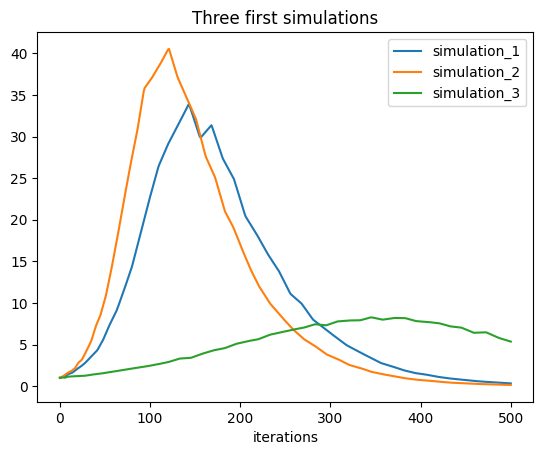

In [139]:
# Plot the three first simulations
fig, ax = plt.subplots()

ax.plot(range(dfInfected.shape[1]), dfInfected.loc[1,:], label="simulation_1")
ax.plot(range(dfInfected.shape[1]), dfInfected.loc[5,:], label="simulation_2")
ax.plot(range(dfInfected.shape[1]), dfInfected.loc[9,:], label="simulation_3")

ax.set_title("Three first simulations")
ax.set_xlabel("iterations")
ax.set_ylabel("")
ax.legend()

plt.show()

In [140]:
# Scale the data using StandardScaler()
dfInfected_arr = dfInfected.to_numpy()
scaler = StandardScaler()
scaler.fit(dfInfected_arr)
dfInfected_arr = scaler.transform(dfInfected_arr)

# Split the data using train_test_split()
dfInfected_train, dfInfected_test = train_test_split(dfInfected_arr, test_size=0.1)
print("The shape of the training and test datasets:", dfInfected_train.shape, dfInfected_test.shape)


The shape of the training and test datasets: (135, 501) (15, 501)
